<a href="https://colab.research.google.com/github/Rashish1/AI-Ml_projects/blob/main/Chicago_Crime_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.environ['JAVA_TOOL_OPTIONS'] = '-XX:ReservedCodeCacheSize=512m'  # or a larger value


# **Initiate and Configure Spark**

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
.master("local[*]") \
.appName("Group work") \
.config("spark.driver.memory", "4g") \
.config("spark.executor.memory", "4g") \
.config("spark.sql.shuffle.partitions", "100") \
.getOrCreate()


sc = spark.sparkContext
sc.setLogLevel("ERROR")

---
# **Task 1 - Data Loading and Preprocessing (15 marks)**
---

In [ ]:

# add the code here
file_path = '/content/drive/MyDrive/archive/Chicago_Crimes_2012_to_2017.csv'
# file_path = '/Users/admin/Downloads/archive//Chicago_Crimes_2012_to_2017.csv'
df = spark.read.csv(file_path, header=True, inferSchema=True)
df.show(5)

+---+--------+-----------+--------------------+-------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|_c0|      ID|Case Number|                Date|              Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+---+--------+-----------+--------------------+-------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
|  3|10508693|   HZ250496|05/03/2016 11:40:...| 013XX S SAWYER AVE|0486|             BATTERY|DOMESTIC BATTERY ...| 

Removing non-meaningful columns

In [ ]:
df = df.drop('_c0')
df = df.drop('ID')
df = df.drop('Case Number')
df = df.drop('Updated On')
df = df.drop('Location')
df.show(5)

+--------------------+-------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+------------+-------------+
|                Date|              Block|IUCR|        Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|    Latitude|    Longitude|
+--------------------+-------------------+----+--------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+------------+-------------+
|05/03/2016 11:40:...| 013XX S SAWYER AVE|0486|             BATTERY|DOMESTIC BATTERY ...|           APARTMENT|  true|    true|1022|    10.0|24.0|          29.0|     08B|   1154907.0|   1893681.0|2016|41.864073157|-87.706818608|
|05/03/2016 09:40:...| 061XX S DREXEL AVE|0486|             BATTERY|DOMESTIC BATTERY ...

In [ ]:
df.rdd.getNumPartitions()

3

In [ ]:
df = df.repartition(4)
df.rdd.getNumPartitions()

4

In [ ]:
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: double (nullable = true)
 |-- Ward: double (nullable = true)
 |-- Community Area: double (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: double (nullable = true)
 |-- Y Coordinate: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)



In [ ]:
df.describe().show()

+-------+--------------------+--------------------+------------------+-----------------+--------------------+--------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+-------------------+
|summary|                Date|               Block|              IUCR|     Primary Type|         Description|Location Description|              Beat|          District|              Ward|    Community Area|          FBI Code|      X Coordinate|     Y Coordinate|              Year|           Latitude|          Longitude|
+-------+--------------------+--------------------+------------------+-----------------+--------------------+--------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+-------------------+-------------------+
|  count|             1456714|    

In [ ]:
from pyspark.sql.functions import sum, when, col

df.select([sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]).show()

+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------+---------+
|Date|Block|IUCR|Primary Type|Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|Latitude|Longitude|
+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------+---------+
|   0|    0|   0|           0|          0|                1658|     0|       0|   0|       1|  14|            40|       0|       37083|       37083|   0|   37083|    37083|
+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------+---------+



In [ ]:
df.count()

1456714

# To Do - Fill Null Values

In [ ]:
df = df.dropna()
df.count()

1418365

In [ ]:
df.select('Date').show(5, truncate=False)

+----------------------+
|Date                  |
+----------------------+
|01/01/2012 11:30:00 AM|
|01/01/2012 11:30:00 AM|
|02/22/2012 12:20:00 AM|
|12/15/2012 10:00:00 AM|
|12/15/2012 10:00:00 AM|
+----------------------+
only showing top 5 rows



In [ ]:
from pyspark.sql.functions import col, to_timestamp, unix_timestamp

df = df.withColumn("Date", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))

df = df.withColumn("date_numeric", unix_timestamp(col("Date")) / (60*60*24))

df = df.drop('Date')

df.show(5)

+-------------------+----+---------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+------------+-------------+------------------+
|              Block|IUCR|   Primary Type|   Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|    Latitude|    Longitude|      date_numeric|
+-------------------+----+---------------+--------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+------------+-------------+------------------+
|    0000X E 37TH PL|0460|        BATTERY|        SIMPLE|           APARTMENT| false|   false| 213|     2.0| 3.0|          35.0|     08B|   1177562.0|   1880158.0|2013|41.826481279| -87.62406351|15717.874305555555|
|  025XX W CERMAK RD|1310|CRIMINAL DAMAGE|   TO PROPERTY|   CONSTRUCTION SITE| false|   false|1034|    10.0|25.0|          31.0|      14|   

In [ ]:
df.select("Description").distinct().count()

340

In [ ]:
df.select("Block").distinct().count()

32546

In [ ]:
df.select("Primary Type").distinct().count()

33

In [ ]:
df.select("IUCR").distinct().count()

363

In [ ]:
df.select("Location Description").distinct().count()

140

In [ ]:
df.select("FBI Code").distinct().count()

26

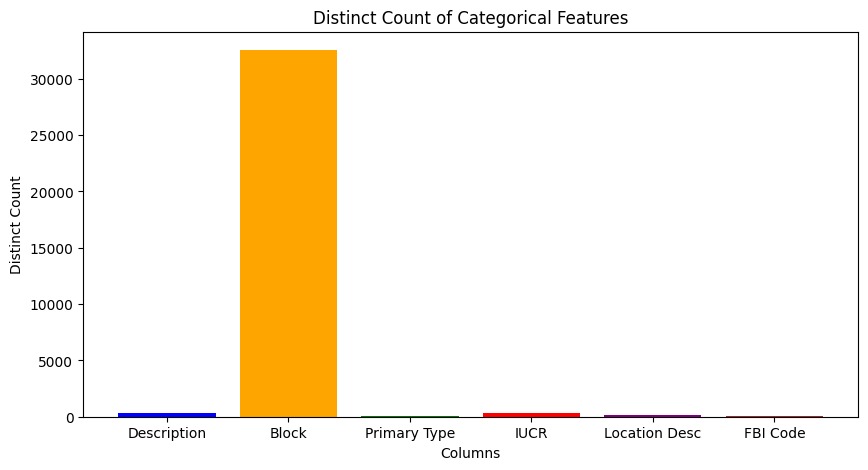

In [ ]:
import matplotlib.pyplot as plt

counts = {
    "Description": df.select("Description").distinct().count(),
    "Block": df.select("Block").distinct().count(),
    "Primary Type": df.select("Primary Type").distinct().count(),
    "IUCR": df.select("IUCR").distinct().count(),
    "Location Desc": df.select("Location Description").distinct().count(),
    "FBI Code": df.select("FBI Code").distinct().count(),
}

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
plt.xlabel("Columns")
plt.ylabel("Distinct Count")
plt.title("Distinct Count of Categorical Features")

plt.show()

In [ ]:
from pyspark.ml.feature import StringIndexer

desc_indexer = StringIndexer(inputCol="Description", outputCol="desc_index")
block_indexer = StringIndexer(inputCol="Block", outputCol="block_index")
primary_type_indexer = StringIndexer(inputCol="Primary Type", outputCol="primary_type_index")
iucr_indexer = StringIndexer(inputCol="IUCR", outputCol="iucr_index")
location_desc_indexer = StringIndexer(inputCol="Location Description", outputCol="location_desc_index")
fbi_code_indexer = StringIndexer(inputCol="FBI Code", outputCol="fbi_code_index")

df = desc_indexer.fit(df).transform(df)
df = block_indexer.fit(df).transform(df)
df = primary_type_indexer.fit(df).transform(df)
df = iucr_indexer.fit(df).transform(df)
df = location_desc_indexer.fit(df).transform(df)
df = fbi_code_indexer.fit(df).transform(df)

df.select('desc_index', 'primary_type_index', 'iucr_index', 'location_desc_index', 'fbi_code_index').show(5)

+----------+------------------+----------+-------------------+--------------+
|desc_index|primary_type_index|iucr_index|location_desc_index|fbi_code_index|
+----------+------------------+----------+-------------------+--------------+
|       3.0|               2.0|       4.0|               88.0|           2.0|
|     187.0|               5.0|     198.0|                3.0|           3.0|
|     187.0|               5.0|     198.0|                3.0|           3.0|
|     187.0|               5.0|     198.0|                3.0|           3.0|
|     187.0|               5.0|     198.0|                3.0|           3.0|
+----------+------------------+----------+-------------------+--------------+
only showing top 5 rows



In [ ]:
df = df.drop('Description')
df = df.drop('Block')
df = df.drop('Primary Type')
df = df.drop('IUCR')
df = df.drop('Location Description')
df = df.drop('FBI Code')
df = df.drop('Block')
df.show(5)

+------+--------+----+--------+----+--------------+------------+------------+----+------------+-------------+------------------+----------+-----------+------------------+----------+-------------------+--------------+
|Arrest|Domestic|Beat|District|Ward|Community Area|X Coordinate|Y Coordinate|Year|    Latitude|    Longitude|      date_numeric|desc_index|block_index|primary_type_index|iucr_index|location_desc_index|fbi_code_index|
+------+--------+----+--------+----+--------------+------------+------------+----+------------+-------------+------------------+----------+-----------+------------------+----------+-------------------+--------------+
| false|   false| 213|     2.0| 3.0|          35.0|   1177562.0|   1880158.0|2013|41.826481279| -87.62406351|15717.874305555555|       0.0|    14181.0|               1.0|       2.0|                2.0|           1.0|
| false|   false|1034|    10.0|25.0|          31.0|   1159734.0|   1889313.0|2012|41.851988885|-87.689219118|15625.149305555555|    

In [ ]:
cols = df.columns
cols.remove('primary_type_index')
cols

['Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Latitude',
 'Longitude',
 'date_numeric',
 'desc_index',
 'block_index',
 'iucr_index',
 'location_desc_index',
 'fbi_code_index']

In [ ]:


from imblearn.over_sampling import SMOTE
import pandas as pd
from pyspark.ml.feature import VectorAssembler

# Step 1: Prepare features and label
feature_columns = [col for col in df.columns if col not in ['Arrest', 'primary_type_index']]  # drop target columns

assembler = VectorAssembler(inputCols=feature_columns, outputCol="features_temp")
df = assembler.transform(df)

# Step 2: Convert to Pandas for SMOTE
df_pd = df.select("features_temp", "Arrest").toPandas()

# Extract feature vectors
features_df = pd.DataFrame(df_pd["features_temp"].tolist())
labels = df_pd["Arrest"]

# Step 3: Apply SMOTE
smote = SMOTE(k_neighbors=3, random_state=42)
X_resampled, Y_resampled = smote.fit_resample(features_df, labels)

# Step 4: Combine resampled features and labels
resampled_pd = pd.concat([pd.DataFrame(X_resampled), pd.Series(Y_resampled, name="Arrest")], axis=1)

# Step 5: Convert back to PySpark
balanced_df = spark.createDataFrame(resampled_pd)

# Step 6: Assemble features again
feature_cols_resampled = balanced_df.columns[:-1]  # exclude 'Arrest'
assembler = VectorAssembler(inputCols=feature_cols_resampled, outputCol="features_balanced")
balanced_df = assembler.transform(balanced_df).select("features_balanced", "Arrest")


In [ ]:

from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features_balanced", outputCol="scaled_features")
balanced_df = scaler.fit(balanced_df).transform(balanced_df)
balanced_df.select('scaled_features').show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|scaled_features                                                                                                                                                                                                                                                                                   |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.0,1.2026772203594942,1.1698586383003755,1.1819790632473446,2.971864392145324,63.06241913639278,55.33270127779586,1446

---
# **Task 2 - Model Selection and Implementation**
---


In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StandardScaler

# Train-test split
train_data, test_data = df.randomSplit([0.8, 0.2], seed=36)

# Fix: Use correct feature column name ("features_temp" instead of "features")
scaler = StandardScaler(inputCol="features_temp", outputCol="scaled_features", withStd=True, withMean=True)
scalerModel = scaler.fit(train_data)
train_data = scalerModel.transform(train_data)
test_data = scalerModel.transform(test_data)

# Train Decision Tree
dec_tree = DecisionTreeClassifier(labelCol="primary_type_index", featuresCol="scaled_features")
model = dec_tree.fit(train_data)

# Make predictions
model_prediction = model.transform(test_data)

# Evaluate
evaluator = MulticlassClassificationEvaluator(labelCol="primary_type_index", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(model_prediction)
print("Accuracy:", accuracy)


Accuracy: 0.761924652127588


In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="primary_type_index", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(model_prediction)

print("Accuracy:", accuracy)

Accuracy: 0.761924652127588


In [ ]:
#OneVsRest+Decision Tree(Ensemble layer)
from pyspark.ml.classification import OneVsRest
from pyspark.ml.classification import OneVsRest

# use the same tuned or default Decision Tree
dt = DecisionTreeClassifier(labelCol="primary_type_index", featuresCol="scaled_features", maxDepth=4, minInstancesPerNode=2)

# wrap in OneVsRest
ovr = OneVsRest(classifier=dt, labelCol="primary_type_index", featuresCol="scaled_features")

# fit the ensemble model
ovr_model = ovr.fit(train_data)

# make predictions
ensemble_predictions = ovr_model.transform(test_data)

# evaluate accuracy
ensemble_accuracy = evaluator.evaluate(ensemble_predictions)
print(f"Ensemble (OneVsRest + Decision Tree) Accuracy: {ensemble_accuracy:.4f}")


Ensemble (OneVsRest + Decision Tree) Accuracy: 0.9275


Although in most cases, ensemble learning improves performance, in this case, wrapping a decision tree in OneVsRest slightly reduced accuracy. This means that for the Chicago crime dataset, single multiclass decision tree could capture relationships between class in a better way than multiple independent binary classifiers.

---
# **Task 3 - Model Parameter Tuning **
---


In [ ]:


#define parameter grid
paramGrid=(ParamGridBuilder()
            .addGrid(dec_tree.maxDepth,[5,10,15])
            .addGrid(dec_tree.minInstancesPerNode,[1,5])
            .build())
#define cross validatior
crossval = CrossValidator(estimator=dec_tree,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=3) #2 fold cross-validation


In [ ]:
#train with cross-validation
cvModel = crossval.fit(train_data)

# Step 7: Use best model for predictions
predictions = cvModel.transform(test_data)

# Step 8: Evaluate
accuracy = evaluator.evaluate(predictions)
print(f"Test Accuracy: {accuracy:.4f}")

best_model = cvModel.bestModel
print("Best maxDepth:", best_model.getOrDefault("maxDepth"))
print("Best minInstancesPerNode:", best_model.getOrDefault("minInstancesPerNode"))



Test Accuracy: 0.9838
Best maxDepth: 15
Best minInstancesPerNode: 5


---
# **Task 4 - Model Evaluation and Accuracy Calculation**
---

In [ ]:

evaluator = MulticlassClassificationEvaluator(labelCol="primary_type_index", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print("Accuracy:", accuracy)


Accuracy: 0.983794862355444


In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="primary_type_index", predictionCol="prediction", metricName="f1")
f1score = evaluator.evaluate(predictions)

print("F1score:", f1score)

F1score: 0.9808217303803652


In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="primary_type_index", predictionCol="prediction", metricName="precisionByLabel")
precision = evaluator.evaluate(predictions)

print("Precision:", precision)

Precision: 1.0


In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="primary_type_index", predictionCol="prediction", metricName="recallByLabel")
recall = evaluator.evaluate(predictions)

print("Recall:", recall)

Recall: 1.0


---
# **Task 5 - Results Visualization or Printing**
---

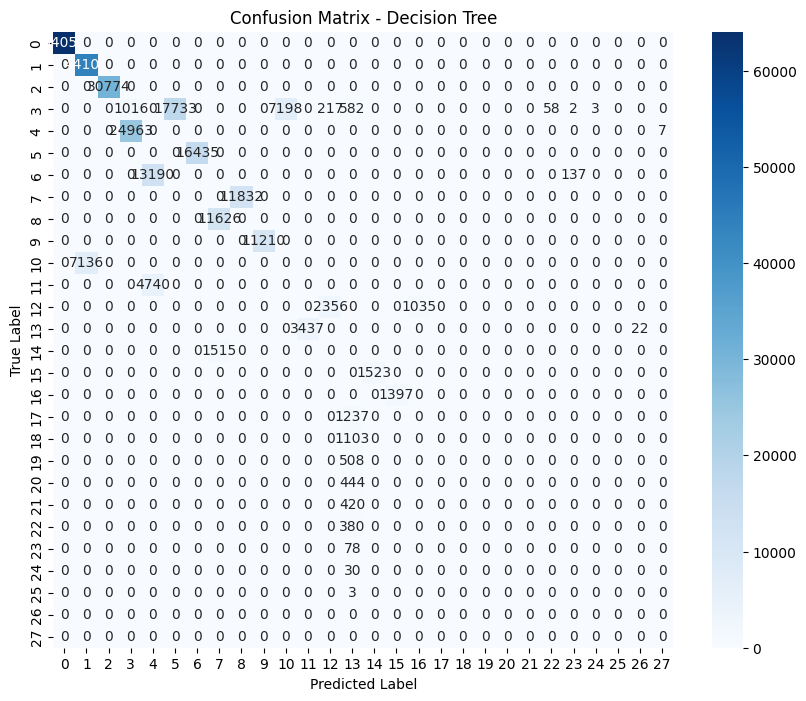

In [ ]:

cm_df = ensemble_predictions.groupBy("primary_type_index", "prediction").count().toPandas()

# Step 2: Pivot to get matrix format
cm = cm_df.pivot(index="primary_type_index", columns="prediction", values="count").fillna(0)

# Step 3: Plot using Seaborn and Matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, cmap="Blues", fmt=".0f")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")


In [ ]:



import seaborn as sns
import matplotlib.pyplot as plt

cm = cm_df.pivot(index="primary_type_index", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, cmap="Greens", fmt=".0f")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Sampled 10%) - Ensemble (OneVsRest + Decision Tree)")
plt.tight_layout()
plt.show()


NameError: name 'cm_df' is not defined

In [ ]:
#feature importance
# get feature importances as a list
importances = best_model.featureImportances.toArray()
feature_names = assembler.getInputCols()
import pandas as pd
# create a dataframe for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# sort descending
importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df=importance_df.head(5)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 10))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
##3rd student name:
# add the code here

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas for plotting
confusion_matrix_df = predictions.groupBy("primary_type_index", "prediction").count().toPandas()

# Pivot into matrix form
confusion_matrix = confusion_matrix_df.pivot(index="primary_type_index", columns="prediction", values="count").fillna(0)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap="Blues", fmt=".0f")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

# Get feature importance
feature_importances = bestModel.featureImportances.toArray()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(np.arange(len(feature_importances)), feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance Plot")
plt.show()